**----------  Project 06: Data Visualization Mastery with Seaborn   ---------------**

Create an Interactive Sales Dashboard with multiple chart types showing sales trends, customer segmentation, and product performance

**Requirements:**
1. Use Seaborn for statistical plots
2. Create at least 5 different chart types
3. Build interactive elements with Plotly
4. Design cohesive color scheme
5. Create professional dashboard layout

In [4]:
#    Install Libraries

!pip install plotly seaborn

In [2]:
#  Importing all Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [6]:
#  Load the Uploaded CSV File

df = pd.read_csv('/content/sales_data.csv')

df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [9]:
#  Check Dataset

print(df.shape)

print(df.columns)

df.info()

(100, 7)
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [10]:
#  Data Cleaning

# Convert Date column into datetime
df['Date'] = pd.to_datetime(df['Date'])

# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

df.head()

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [12]:
#  Dashboard Theme

sns.set_style("darkgrid")

sns.set_palette("viridis")

plt.rcParams['figure.figsize'] = (12,6)

In [13]:
#  KPI Metrics

total_sales = df['Total_Sales'].sum()

total_quantity = df['Quantity'].sum()

average_sales = df['Total_Sales'].mean()

total_customers = df['Customer_ID'].nunique()

print("Total Sales:", total_sales)

print("Total Quantity Sold:", total_quantity)

print("Average Sales:", average_sales)

print("Total Customers:", total_customers)

Total Sales: 12365048
Total Quantity Sold: 478
Average Sales: 123650.48
Total Customers: 100


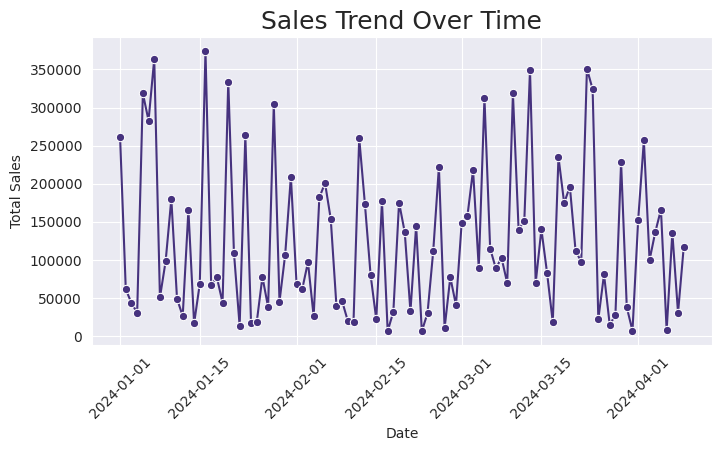

In [17]:
#  Sales Trend Line Chart

sales_trend = df.groupby('Date')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(8,4))

sns.lineplot(
    data=sales_trend,
    x='Date',
    y='Total_Sales',
    marker='o'
)

plt.title('Sales Trend Over Time', fontsize=18)

plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

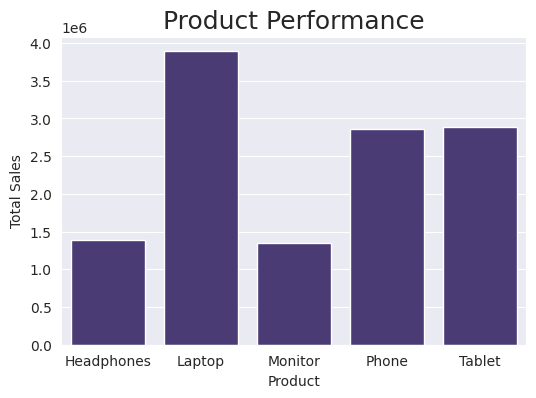

In [21]:
#  Product Performance Bar Chart

product_sales = df.groupby('Product')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(6,4))

sns.barplot(
    data=product_sales,
    x='Product',
    y='Total_Sales'
)

plt.title('Product Performance', fontsize=18)
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.show()

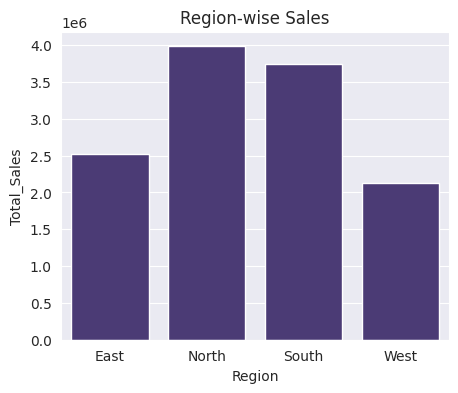

In [22]:
#  Region-wise Sales

region_sales = df.groupby('Region')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(5,4))

sns.barplot(
    data=region_sales,
    x='Region',
    y='Total_Sales'
)

plt.title('Region-wise Sales')
plt.show()

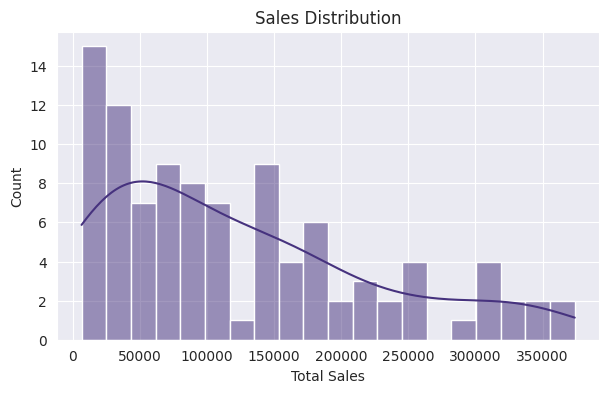

In [23]:
#  Sales Distribution Histogram

plt.figure(figsize=(7,4))

sns.histplot(
    df['Total_Sales'],
    bins=20,
    kde=True
)

plt.title('Sales Distribution')
plt.xlabel('Total Sales')
plt.show()

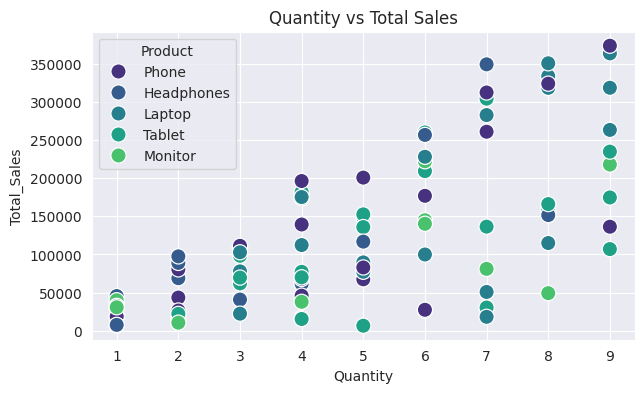

In [24]:
# Quantity vs Sales Scatter Plot

plt.figure(figsize=(7,4))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total_Sales',
    hue='Product',
    s=120
)

plt.title('Quantity vs Total Sales')
plt.show()

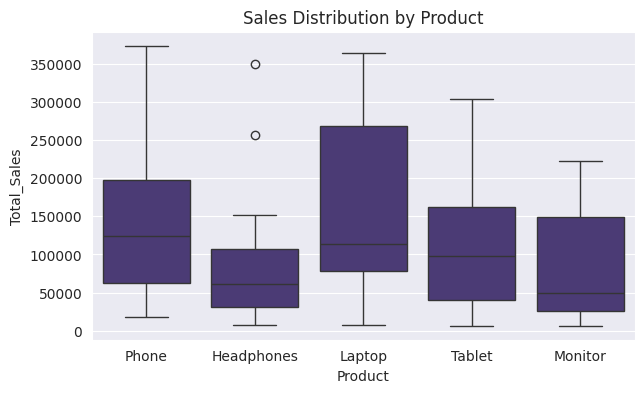

In [25]:
#  Box Plot (Product Sales Distribution)

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x='Product',
    y='Total_Sales'
)

plt.title('Sales Distribution by Product')
plt.show()

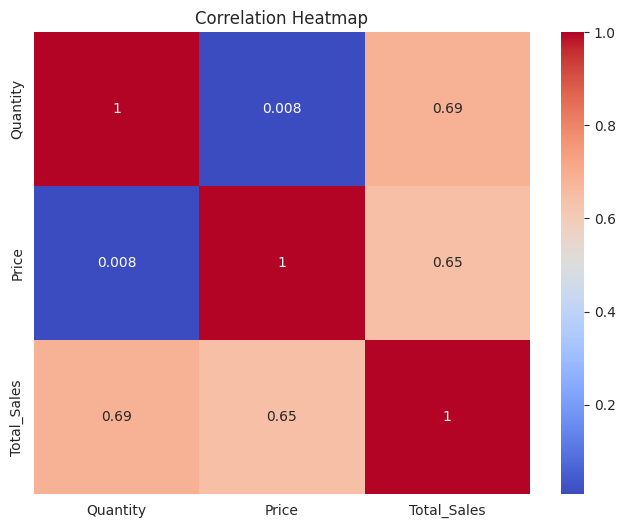

In [26]:
#  Correlation Heatmap

numeric_df = df[['Quantity', 'Price', 'Total_Sales']]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

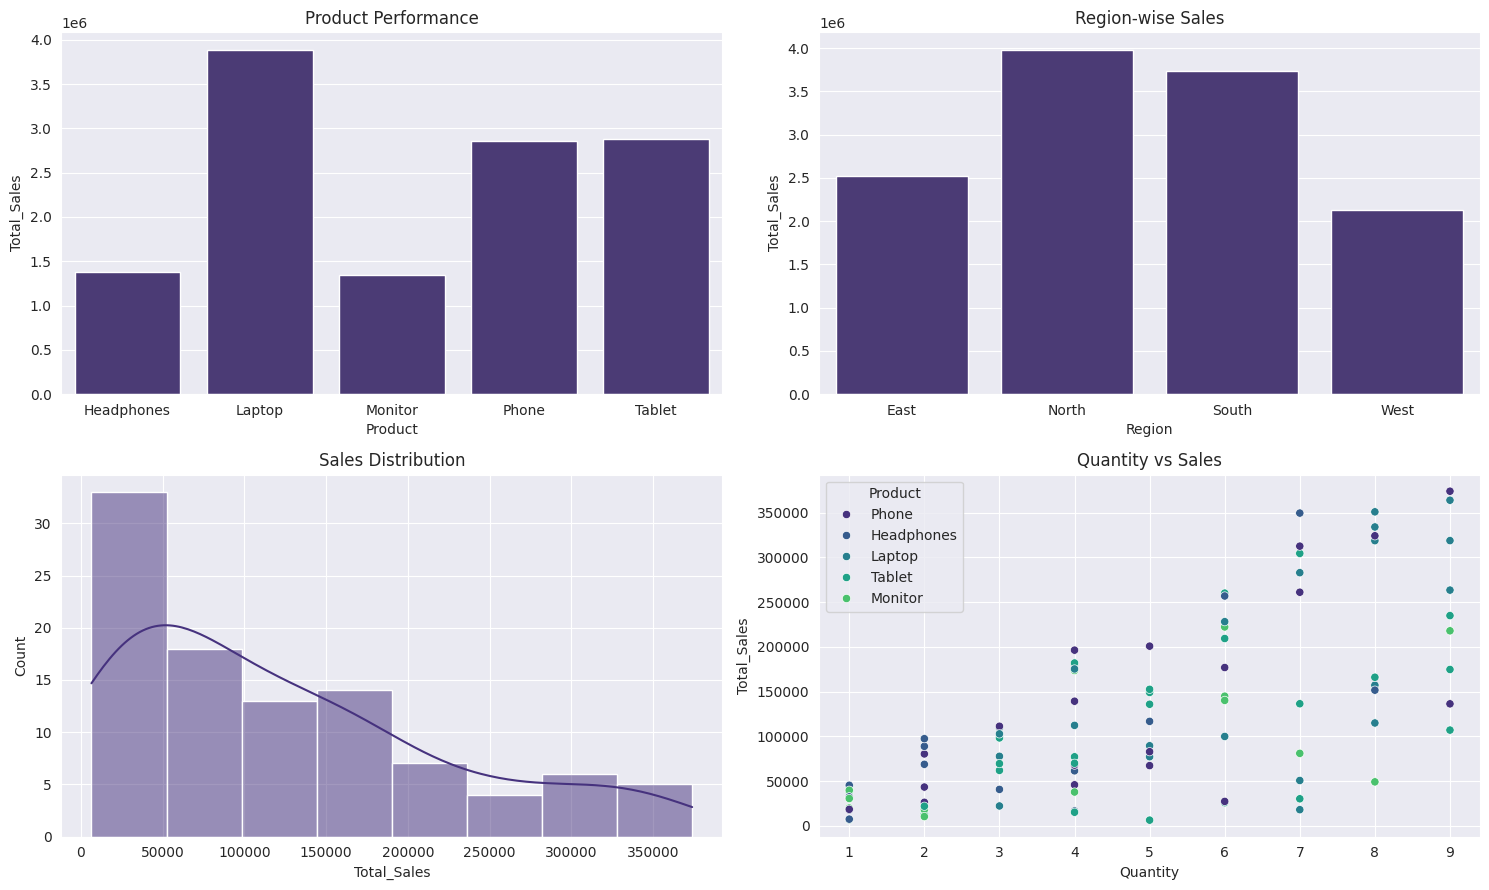

In [29]:
#  Professional Multi-Chart Dashboard

fig, axes = plt.subplots(2, 2, figsize=(15,9))

# Product Sales
sns.barplot(
    data=product_sales,
    x='Product',
    y='Total_Sales',
    ax=axes[0,0]
)

axes[0,0].set_title("Product Performance")

# Region Sales
sns.barplot(
    data=region_sales,
    x='Region',
    y='Total_Sales',
    ax=axes[0,1]
)

axes[0,1].set_title("Region-wise Sales")

# Histogram
sns.histplot(
    df['Total_Sales'],
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title("Sales Distribution")

# Scatter Plot
sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total_Sales',
    hue='Product',
    ax=axes[1,1]
)

axes[1,1].set_title("Quantity vs Sales")

plt.tight_layout()
plt.show()

In [42]:
#  Interactive Plotly Line Chart

fig =px.line(
    sales_trend,
    x='Date',
    y='Total_Sales',
    title='Interactive Sales Trend',
    markers=True
)
fig.update_layout(
    width=900,
    height=500
)
fig.show()

In [43]:
#  Interactive Product Dashboard

fig = px.bar(
    product_sales,
    x='Product',
    y='Total_Sales',
    color='Product',
    title='Interactive Product Performance'
)
fig.update_layout(
    width=900,
    height=500
)
fig.show()

In [44]:
#   Interactive Scatter Plot

fig = px.scatter(
    df,
    x='Quantity',
    y='Total_Sales',
    color='Product',
    hover_data=['Region', 'Price'],
    size='Price',
    title='Interactive Quantity vs Sales'
)
fig.update_layout(
    width=900,
    height=500
)
fig.show()

In [47]:
#  FINAL INTERACTIVE SALES DASHBOARD

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        'Sales Trend',
        'Product Performance',
        'Region Sales',
        'Quantity vs Sales'
    )
)

# Sales Trend
fig.add_trace(
    go.Scatter(
        x=sales_trend['Date'],
        y=sales_trend['Total_Sales'],
        mode='lines+markers',
        name='Sales Trend'
    ),
    row=1,
    col=1
)

# Product Performance
fig.add_trace(
    go.Bar(
        x=product_sales['Product'],
        y=product_sales['Total_Sales'],
        name='Products'
    ),
    row=1,
    col=2
)

# Region Sales
fig.add_trace(
    go.Bar(
        x=region_sales['Region'],
        y=region_sales['Total_Sales'],
        name='Regions'
    ),
    row=2,
    col=1
)

# Scatter Plot
fig.add_trace(
    go.Scatter(
        x=df['Quantity'],
        y=df['Total_Sales'],
        mode='markers',
        name='Sales Scatter'
    ),
    row=2,
    col=2
)

fig.update_layout(
    height=800,
    width=1400,
    title_text="Interactive Sales Dashboard",
    template="plotly_dark",
    showlegend=False
)

fig.show()

In [48]:
#  Save Dashboard

plt.savefig("sales_dashboard.png")

<Figure size 1200x600 with 0 Axes>